# Configuración de Redes Neuronales: Parámetros y Opciones Clave
Este Jupyter Notebook tiene como objetivo explicar de manera práctica y estructurada cómo configurar una red neuronal para el aprendizaje (entrenamiento). Veremos los componentes esenciales que se definen antes de entrenar un modelo, sus parámetros, variantes principales y cómo implementarlos usando **TensorFlow/Keras**.

---



In [25]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [26]:

housing = fetch_california_housing()
X, y = housing.data, housing.target
df = pd.DataFrame(housing.data, columns= housing.feature_names)
df["y"] = housing.target

df


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,y
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [27]:
X = df.drop(columns="y")
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
X_train.shape

(16512, 8)

## 1. Configuración de la Estructura Básica (Capas y Activaciones)

Antes de compilar y entrenar, la red se define por su arquitectura. Cada capa requiere una cantidad de unidades (neuronas) y una **Función de Activación**.

### Funciones de Activación Comunes:
* `'relu'` (Rectified Linear Unit): La más utilizada en capas ocultas. Evita el desvanecimiento del gradiente y es computacionalmente eficiente.
* `'sigmoid'`: Escala los valores entre 0 y 1. Ideal para clasificación binaria en la capa de salida.
* `'softmax'`: Escala los valores para que sumen 1. Ideal para clasificación multiclase en la capa de salida.
* `'tanh'` (Tangente hiperbólica): Escala entre -1 y 1. Útil en ciertas arquitecturas ocultas.

In [29]:
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(8,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1,activation= 'linear')
])

model.summary()

c:\Users\Diego Nuñez\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

## 2. El Método `.compile()`: Configurando el Aprendizaje

Una vez definida la estructura, debemos indicarle a la red **cómo** va a aprender. Esto se configura mediante tres pilares:

### A. Función de Pérdida (`loss`)
Determina cómo se cuantifica el error del modelo. La elección depende exclusivamente del tipo de problema:
* **Clasificación Binaria:** `'binary_crossentropy'`
* **Clasificación Multiclase (etiquetas One-Hot):** `'categorical_crossentropy'`
* **Clasificación Multiclase (etiquetas como enteros numéricos):** `'sparse_categorical_crossentropy'`
* **Regresión (Predecir números continuos):** `'mse'` (Mean Squared Error) o `'mae'` (Mean Absolute Error)

### B. Optimizador (`optimizer`)
Es el algoritmo encargado de actualizar los pesos de la red basándose en el gradiente de la función de pérdida.
* `'adam'`: (Adaptive Moment Estimation) El estándar de la industria. Adapta el learning rate para cada parámetro individualmente.
* `'sgd'`: (Stochastic Gradient Descent) El método clásico. Puede complementarse con `momentum` para acelerar la convergencia.
* `'rmsprop'`: Excelente para redes neuronales recurrentes (RNN) y problemas con datos temporales.

### C. Métricas (`metrics`)
Se utilizan para monitorear el rendimiento del modelo de una manera inteligible para el usuario.
* `['accuracy']`: Porcentaje de predicciones correctas (Clasificación).
* `['mae']`: Error absoluto medio (Regresión).

In [34]:
model.compile(
    optimizer='adam',
    loss='mse',  # Error Cuadrático Medio
    metrics=['mae'] # Error Absoluto Medio (fácil de interpretar)
)

## 3. El Método `.fit()`: Parámetros del Entrenamiento

El entrenamiento consiste en alimentar a la red con los datos utilizando el método `.fit()`. Aquí configuramos la dinámica del proceso mediante los siguientes hiperparámetros fundamentales:

* **`X` e `y` (Datos y Etiquetas):** Las entradas de entrenamiento junto con sus respuestas correctas (valores objetivo).
* **`epochs` (Épocas):** Cuántas veces pasará el conjunto de datos completo (hacia adelante y hacia atrás) a través de la red neuronal durante el entrenamiento.
    * *Pocas épocas:* Generan un modelo poco entrenado (*underfitting*).
    * *Demasiadas épocas:* Generan sobreajuste (*overfitting*), memorizando los datos en vez de generalizar.
* **`batch_size` (Tamaño del lote):** El número de muestras de entrenamiento que la red procesa en paralelo antes de calcular el gradiente y actualizar sus pesos internos.
    * *Lotes pequeños (32, 64):* Requieren menos memoria RAM/VRAM, añaden un "ruido" al gradiente que ayuda a escapar de mínimos locales, pero el entrenamiento tarda más tiempo por época.
    * *Lotes grandes (256, 512):* Aprovechan mejor la aceleración de hardware (GPU), producen gradientes más estables, pero pueden converger en soluciones menos óptimas si el learning rate no se ajusta.
* **`validation_split` / `validation_data`:** 
    * `validation_split=0.2` extrae automáticamente el último 20% de los datos introducidos para evaluar las métricas de pérdida (`val_loss`) y precisión (`val_accuracy`) al término de cada época.
    * Crucial para evaluar cómo rinde el modelo ante datos que no se usan para ajustar los pesos.
* **`verbose`:** Controla qué tanta información se imprime en consola durante el proceso (`0` = silencio, `1` = barra de progreso animada por época, `2` = una línea resumen por época).

In [31]:
historial = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2.2613 - mae: 0.9636 - val_loss: 0.4719 - val_mae: 0.4821
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4297 - mae: 0.4611 - val_loss: 0.4176 - val_mae: 0.4574
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3927 - mae: 0.4418 - val_loss: 0.4163 - val_mae: 0.4627
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3799 - mae: 0.4307 - val_loss: 0.3861 - val_mae: 0.4432
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3689 - mae: 0.4252 - val_loss: 0.3991 - val_mae: 0.4646
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3382 - mae: 0.4147 - val_loss: 0.3741 - val_mae: 0.4411
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3388 - mae: 0.4133 - val_loss: 0.3793 - val_mae: 0.4513
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3484 - mae: 0.4194 - val_loss: 0.3664 - val_mae: 0.4142
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - lo

## 4. Parámetros Avanzados: Controlando el Aprendizaje dinámicamente con Callbacks

Para evitar que la red sufra de *overfitting* o se estanque cuando se entrena con un número alto de épocas, se pasan funciones especiales al argumento `callbacks` de `.fit()`:

* **`EarlyStopping` (Parada Temprana):** Detiene el entrenamiento automáticamente si la métrica de validación (`val_loss`) deja de mejorar tras un número determinado de épocas fijado en `patience`.
* **`ReduceLROnPlateau`:** Disminuye de forma automática el Learning Rate (tasa de aprendizaje) si el rendimiento en el set de validación se estanca, permitiendo pasos más pequeños y finos.

In [32]:
callbacks = [
    EarlyStopping(
        monitor='val_loss', 
        patience=2,          
    )
]

historial_avanzado = model.fit(
    X_train, 
    y_train,
    epochs=50,               
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks, 
    verbose=1
)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2790 - mae: 0.3639 - val_loss: 0.3119 - val_mae: 0.3782
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2843 - mae: 0.3681 - val_loss: 0.3079 - val_mae: 0.3789
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2800 - mae: 0.3674 - val_loss: 0.3113 - val_mae: 0.3916
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2745 - mae: 0.3638 - val_loss: 0.3134 - val_mae: 0.3820


## 5. Resumen de Opciones de Configuración

| Parámetro / Componente | Opciones Principales | Propósito |
| :--- | :--- | :--- |
| **Capas Ocultas (`Dense`)** | Enteros (ej. 32, 64, 128...) | Capacidad de abstracción de la red |
| **Activación Oculta** | `'relu'`, `'tanh'` | Añadir no-linealidad a los patrones |
| **Activación Salida** | `'sigmoid'` (Binaria), `'softmax'` (Multiclase) | Adaptar la salida al tipo de predicción |
| **Optimizador (`optimizer`)**| `'adam'`, `'sgd'`, `'rmsprop'` | Algoritmo que ajusta los pesos |
| **Tasa de Aprendizaje (`lr`)**| Flotantes pequeños (ej. `0.01`, `0.001`) | Velocidad de ajuste del optimizador |
| **Función de Pérdida (`loss`)**| `'binary_crossentropy'`, `'sparse_categorical_crossentropy'`, `'mse'` | Fórmula matemática para medir el error |
| **Tamaño de Lote (`batch_size`)**| Potencias de 2 (32, 64, 128...) | Muestras procesadas antes de actualizar |
| **Épocas (`epochs`)** | Enteros (ej. 10, 50, 100...) | Iteraciones totales sobre el dataset |

# Red completa


In [ ]:
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(8,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1,activation= 'linear')
])

model.compile(
    optimizer='adam',
    loss='mse',  # Error Cuadrático Medio
    metrics=['mae', 'mse'] # Error Absoluto Medio (fácil de interpretar)
)

historial = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20


c:\Users\Diego Nuñez\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2.2243 - mae: 0.9362 - val_loss: 0.4833 - val_mae: 0.4938
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4229 - mae: 0.4603 - val_loss: 0.4117 - val_mae: 0.4497
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3825 - mae: 0.4353 - val_loss: 0.4060 - val_mae: 0.4505
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3606 - mae: 0.4245 - val_loss: 0.4052 - val_mae: 0.4314
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3951 - mae: 0.4301 - val_loss: 0.3986 - val_mae: 0.4227
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3418 - mae: 0.4100 - val_loss: 0.4242 - val_mae: 0.4242
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5032 - mae: 0.4019 - val_loss: 0.3574 - val_mae: 0.4266
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3217 - mae: 0.3971 - val_loss: 0.3508 - val_mae: 0.4115
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3143 

In [38]:
historial.params

{'verbose': 1, 'epochs': 20, 'steps': 413}

In [39]:
pred = model.predict(X_test)
pred

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[0.7212999],
       [1.0410862],
       [4.483837 ],
       ...,
       [4.841893 ],
       [0.7822491],
       [1.893206 ]], dtype=float32)

In [40]:
from sklearn import metrics

print(metrics.mean_absolute_error(y_test, pred))

0.385525438830201


In [ ]:
loss, mae = model.evaluate

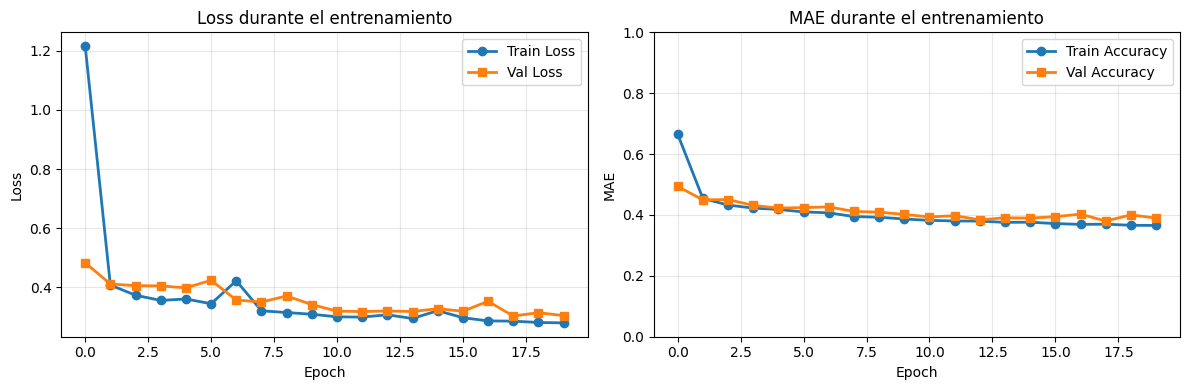

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(historial.history['loss'], label='Train Loss', linewidth=2, marker='o')
axes[0].plot(historial.history['val_loss'], label='Val Loss', linewidth=2, marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss durante el entrenamiento')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(historial.history['mae'], label='Train Accuracy', linewidth=2, marker='o')
axes[1].plot(historial.history['val_mae'], label='Val Accuracy', linewidth=2, marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE durante el entrenamiento')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()